In [2]:
import numpy as np
import math
from scipy.optimize import brentq
import numpy as np
import matplotlib.pyplot as plt


## Question 1 - Part 1 ##
A groundwater sample contains 2.0mmol/L dissolved CO2 and holds a pH of 6.00 at 25℃. (1) Calculate concentrations of H2CO3, HCO3-, and CO3(2-).

In [3]:
def carbonate_speciation(CO2_total_mmol_per_L, pH, temp_C=25):
    """
    Calculate carbonate system speciation from dissolved CO2 and pH.
    
    Parameters:
        CO2_total_mmol_per_L : float  - total dissolved CO2 in mmol/L
        pH                   : float  - measured pH
        temp_C               : float  - temperature in Celsius (default 25)
    
    Returns:
        dict with concentrations of H2CO3, HCO3-, CO3^2- in mmol/L
    """
    
    # --- Equilibrium constants at 25°C ---
    K1 = 10**(-1.47)   # CO2(aq) + H2O  <-> H2CO3
    K2 = 10**(-6.35)   # H2CO3           <-> H+  + HCO3-
    K3 = 10**(-10.33)  # HCO3-           <-> H+  + CO3^2-

    # Convert CO2 from mmol/L to mol/L for calculations
    CO2_aq = CO2_total_mmol_per_L / 1000  # mol/L

    H = 10**(-pH)  # [H+] in mol/L

    # --- Speciation ---
    # K1 = [H2CO3] / [CO2(aq)]  =>  [H2CO3] = K1 * [CO2(aq)]
    H2CO3 = K1 * CO2_aq

    # K2 = [H+][HCO3-] / [H2CO3]  =>  [HCO3-] = K2 * [H2CO3] / [H+]
    HCO3  = (K2 * H2CO3) / H

    # K3 = [H+][CO3^2-] / [HCO3-]  =>  [CO3^2-] = K3 * [HCO3-] / [H+]
    CO3   = (K3 * HCO3) / H

    # Convert back to mmol/L
    H2CO3_mmol = H2CO3 * 1000
    HCO3_mmol  = HCO3  * 1000
    CO3_mmol   = CO3   * 1000

    # --- Print results ---
    print(f"{'='*45}")
    print(f"  Q1 #1: Carbonate Speciation Results at {temp_C}°C")
    print(f"  Reference slides: 3 Dissolution/precipitation slides")
    print(f"  See code for equations")
    print(f"{'='*45}")
    print(f"  Input CO2(aq)  :  {CO2_total_mmol_per_L:.3f}  mmol/L")
    print(f"  Input pH       :  {pH}")
    print(f"{'-'*45}")
    print(f"  [H2CO3]        :  {H2CO3_mmol:.2e}  mmol/L")
    print(f"  [HCO3-]        :  {HCO3_mmol:.2e}  mmol/L")
    print(f"  [CO3^2-]       :  {CO3_mmol:.2e}  mmol/L")
    print(f"{'-'*45}")
    total = H2CO3_mmol + HCO3_mmol + CO3_mmol
    print(f"  Total carbonate:  {total:.2e}  mmol/L")
    print(f"{'='*45}")

    return {
        "H2CO3_mmol_L":  H2CO3_mmol,
        "HCO3_mmol_L":   HCO3_mmol,
        "CO3_mmol_L":    CO3_mmol
    }


# --- Fill in CO2 concentration and pH here ---
results = carbonate_speciation(CO2_total_mmol_per_L=2.0, pH=6.0)


  Q1 #1: Carbonate Speciation Results at 25°C
  Reference slides: 3 Dissolution/precipitation slides
  See code for equations
  Input CO2(aq)  :  2.000  mmol/L
  Input pH       :  6.0
---------------------------------------------
  [H2CO3]        :  6.78e-02  mmol/L
  [HCO3-]        :  3.03e-02  mmol/L
  [CO3^2-]       :  1.42e-06  mmol/L
---------------------------------------------
  Total carbonate:  9.80e-02  mmol/L


## Question 1 - Part 2 ##
If this groundwater flows through calcite, and the initial Ca2+ concentration in the groundwater is 0, will calcite dissolve or precipitate? 

In [4]:
def calcite_saturation(Ca_mmol_per_L, CO3_mmol_per_L, temp_C=25):
    """
    Calculate the Saturation Index (SI) for calcite.
    
    Parameters:
        Ca_mmol_per_L  : float - concentration of Ca2+ in mmol/L
        CO3_mmol_per_L : float - concentration of CO3^2- in mmol/L (from speciation output)
        temp_C         : float - temperature in Celsius (default 25)
    
    Returns:
        dict with IAP, Ksp, and SI
    """

    # Ksp for calcite at 25°C
    Ksp = 10**(-8.48)

    # Convert mmol/L to mol/L
    Ca  = Ca_mmol_per_L  / 1000
    CO3 = CO3_mmol_per_L / 1000

    # Ion Activity Product (assuming activity coefficients = 1 for dilute solution)
    IAP = Ca * CO3

    # Saturation Index
    if IAP == 0:
        SI = float('-inf')  # completely undersaturated, log(0) is undefined
    else:
        SI = np.log10(IAP / Ksp)

    # --- Print results ---
    print(f"{'='*45}")
    print(f"  Q1 #2: Calcite Saturation Index at {temp_C}°C")
    print(f"  Reference slides: 3 Dissolution/precipitation slides")
    print(f"  See code for equations")
    print(f"{'='*45}")
    print(f"  [Ca2+]         :  {Ca_mmol_per_L:.6e}  mmol/L")
    print(f"  [CO3^2-]       :  {CO3_mmol_per_L:.6e}  mmol/L")
    print(f"{'-'*45}")
    print(f"  IAP            :  {IAP:.6e}")
    print(f"  Ksp (calcite)  :  {Ksp:.6e}")
    print(f"  SI             :  {SI:.4f}")
    print(f"{'-'*45}")

    if IAP == 0 or SI < 0:
        print(f"  Result: UNDERSATURATED -> Calcite DISSOLVES")
    elif SI == 0:
        print(f"  Result: AT EQUILIBRIUM -> No net reaction")
    else:
        print(f"  Result: OVERSATURATED  -> Calcite PRECIPITATES")

    print(f"{'='*45}")

    return {
        "IAP": IAP,
        "Ksp": Ksp,
        "SI":  SI
    }

# Pull CO3 result directly from speciation output above
Ca_concentration = 0.0

sat_results = calcite_saturation(
    Ca_mmol_per_L  = Ca_concentration,
    CO3_mmol_per_L = results["CO3_mmol_L"]  # automatically uses output from speciation cell
)

  Q1 #2: Calcite Saturation Index at 25°C
  Reference slides: 3 Dissolution/precipitation slides
  See code for equations
  [Ca2+]         :  0.000000e+00  mmol/L
  [CO3^2-]       :  1.415892e-06  mmol/L
---------------------------------------------
  IAP            :  0.000000e+00
  Ksp (calcite)  :  3.311311e-09
  SI             :  -inf
---------------------------------------------
  Result: UNDERSATURATED -> Calcite DISSOLVES


## Question 1 - Part 3 ##
Estimate final Ca2+ concentration at equilibrium.

In [5]:
# ── Constants (must match speciation cell) ──────────────────────────────
K1  = 10**(-1.47)    # CO2(aq) -> H2CO3
K2  = 10**(-6.35)    # H2CO3   -> H+ + HCO3-
K3  = 10**(-10.33)   # HCO3-   -> H+ + CO3^2-
Ksp = 10**(-8.48)    # calcite solubility
Kw  = 1e-14          # water dissociation

# ── Pull H2CO3 from speciation results ──────────────────────────────────
# 'results' dict comes from carbonate_speciation() cell
H2CO3 = results["H2CO3_mmol_L"] / 1000   # convert mmol/L -> mol/L


# ── Charge balance function ──────────────────────────────────────────────────
def f_H(H, K2, K3, H2CO3, Ksp, Kw):
    """
    Charge balance: 2[Ca2+] + [H+] = [HCO3-] + 2[CO3^2-] + [OH-]
    
    At equilibrium, Ca2+ comes from calcite dissolution:
        [Ca2+] = Ksp / [CO3^2-] = Ksp * H^2 / (K2 * K3 * H2CO3)
    """
    CO3   = (K2 * K3 * H2CO3) / (H**2)          # [CO3^2-] from K2, K3
    Ca    = Ksp / CO3                             # [Ca2+] from Ksp at equilibrium
    HCO3  = (K2 * H2CO3) / H                     # [HCO3-]
    OH    = Kw / H                                # [OH-]

    left  = 2 * Ca + H
    right = HCO3 + 2 * CO3 + OH

    return left - right


# ── Bisection solver in pH space ─────────────────────────────────────────────
def solve_pH_bisect(K2, K3, H2CO3, Ksp, Kw=1e-14, pH_lo=4, pH_hi=12, tol=1e-12):
    def g(pH):
        H = 10**(-pH)
        return f_H(H, K2, K3, H2CO3, Ksp, Kw)

    a, b = pH_lo, pH_hi
    fa, fb = g(a), g(b)

    if fa * fb > 0:
        raise ValueError(f"Root not bracketed between pH {pH_lo} and {pH_hi}. "
                          "Try expanding pH_lo/pH_hi range.")

    for _ in range(200):
        m  = 0.5 * (a + b)
        fm = g(m)
        if abs(fm) < tol or (b - a) < 1e-10:
            return m
        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm

    return 0.5 * (a + b)


# ── Solve ─────────────────────────────────────────────────────────────────────
pH_eq = solve_pH_bisect(K2, K3, H2CO3, Ksp, Kw)

# Back-calculate equilibrium concentrations
H_eq   = 10**(-pH_eq)
CO3_eq = (K2 * K3 * H2CO3) / (H_eq**2)
Ca_eq  = Ksp / CO3_eq
HCO3_eq = (K2 * H2CO3) / H_eq

# ── Print results ─────────────────────────────────────────────────────────────
print(f"{'='*45}")
print(f"  Q1 #3: Equilibrium Results (Calcite Dissolution)")
print(f"  Reference slides: 3 Dissolution/precipitation slides, Numerical solution: bisection slide")
print(f"{'='*45}")
print(f"  pH             :  {pH_eq:.4f}")
print(f"  [Ca2+]         :  {Ca_eq*1000:.4e}  mmol/L")
print(f"  [HCO3-]        :  {HCO3_eq*1000:.4e}  mmol/L")
print(f"  [CO3^2-]       :  {CO3_eq*1000:.4e}  mmol/L")
print(f"{'='*45}")

  Q1 #3: Equilibrium Results (Calcite Dissolution)
  Reference slides: 3 Dissolution/precipitation slides, Numerical solution: bisection slide
  pH             :  7.7289
  [Ca2+]         :  8.1507e-01  mmol/L
  [HCO3-]        :  1.6215e+00  mmol/L
  [CO3^2-]       :  4.0626e-03  mmol/L


Double check

In [6]:
sat_results = calcite_saturation(
    Ca_mmol_per_L  = Ca_eq * 1000,       # equilibrium Ca from the pH solver
    CO3_mmol_per_L = CO3_eq * 1000       # equilibrium CO3 from the pH solver
)

  Q1 #2: Calcite Saturation Index at 25°C
  Reference slides: 3 Dissolution/precipitation slides
  See code for equations
  [Ca2+]         :  8.150715e-01  mmol/L
  [CO3^2-]       :  4.062602e-03  mmol/L
---------------------------------------------
  IAP            :  3.311311e-09
  Ksp (calcite)  :  3.311311e-09
  SI             :  0.0000
---------------------------------------------
  Result: AT EQUILIBRIUM -> No net reaction


## Question 2 - Parameters ##
The USGS Bemidji crude-oil spill site (Minnesota) has been monitored for decades and shows strong reactive transport driven by biodegradation and redox processes. Construct a simplified 1-D reactive transport model for a single plume component, simulating the transport of a conservative tracer (Cl-1) and a reactive species (Fe2+) along a groundwater flow path downgradient of the oil source.

In [7]:
# ── Groundwater Parameters ────────────────────────────────────────────────────
v       = 0.3       # groundwater velocity [m/day]
alpha_L = 1.0       # longitudinal dispersivity [m]
k       = 0.005     # first-order Fe2+ removal rate [1/day]
R       = 2.5       # retardation factor [-] (1 = no retardation, >1 = sorption)

# ── Source Concentrations ─────────────────────────────────────────────────────
C0_Cl   = 20.0      # source concentration of Cl-  [mg/L]
C0_Fe   = 1.8       # source concentration of Fe2+ [mg/L]

# ── Distance Array ────────────────────────────────────────────────────────────
x_points  = np.array([0, 25, 75, 150])          # specific output points [m]
x_profile = np.linspace(0, 200, 500)            # smooth profile for plotting [m]

print("Parameters loaded successfully.")
print(f"  Velocity (v)         : {v} m/day")
print(f"  Dispersivity (α_L)   : {alpha_L} m")
print(f"  Removal rate (k)     : {k} 1/day")
print(f"  Retardation (R)      : {R} [-]")
print(f"  Cl- source (C0)      : {C0_Cl} mg/L")
print(f"  Fe2+ source (C0)     : {C0_Fe} mg/L")

Parameters loaded successfully.
  Velocity (v)         : 0.3 m/day
  Dispersivity (α_L)   : 1.0 m
  Removal rate (k)     : 0.005 1/day
  Retardation (R)      : 2.5 [-]
  Cl- source (C0)      : 20.0 mg/L
  Fe2+ source (C0)     : 1.8 mg/L


## Question 2 - Part 1 ##
Assume Cl- behaves conservatively. According to the steady-state advection-dispersion equation (Eq.1), (a) calculate the dispersion coefficient D. (b) Derive the steady-state concentration profile C(x) for Cl-1, and (c) compute C(x) at x=0, 25, 75, 150 m.

In [12]:
# ── Q1a: Dispersion Coefficient ───────────────────────────────────────────────
# D = alpha_L * v   (mechanical dispersion, dominant in most groundwater problems)
D = alpha_L * v

print(f"{'='*50}")
print(f"  Q2-1: Conservative Cl- Transport")
print(f"{'='*50}")
print(f"\n  Q2-1a: Dispersion Coefficient")
print(f"  Reference slide: 'Reactive transport modeling, 1-D form'")
print(f"  D = α_L × v + D_m")
print(f"  D_m is assumed to be negligible compared to mechanical dispersion, therefore:")
print(f"  D = α_L × v = {alpha_L} × {v} = {D} m²/day")

# ── Q1b: Steady-State Cl- Profile ────────────────────────────────────────────
# Steady-state solution to 1D ADE (no reaction, dC/dt = 0):
#   D * d²C/dx² - v * dC/dx = 0
# Boundary conditions: C(0) = C0, C(x->inf) = 0
# Solution: C(x) = C0 * exp(-v/D * x)   for x >= 0
#
# Note: this is the advection-dominated steady state assuming
# concentration decays due to dilution/dispersion alone.

def C_Cl(x, C0):
    """ Steady-state Cl- concentration profile [mg/L] - conservative, C(x) = C0 """
    return np.full_like(x, C0, dtype=float)

print(f"\n  Q2-1b: Steady-State Profile")
print(f"  Reference slide: 'Conservative solute reactive transport'")
print(f"  Because this is steady-state (no change with time),")
print(f"    the concentration of the conservative solute doesn't change.")
print(f"{'='*50}")
print(f"  NOTE: The hand derivation is in the attached PDF")
print(f"{'='*50}")
print(f"  C(x) = C0")
print(f"       = {C0_Cl}")

# ── Q1c: Compute at specific distances ───────────────────────────────────────
print(f"\n  Q2-1c: Cl- Concentrations at Specific Distances")
print(f"  Reference slide: 'Conservative solute reactive transport'")
print(f"  Calculated using (C(x) = C0)")
print(f"  {'-'*35}")
print(f"  {'x [m]':>8}  {'C(x) [mg/L]':>14}")
print(f"  {'-'*35}")
for x in x_points:
    C = C_Cl(x, C0_Cl)
    print(f"  {x:>8.0f}  {C:>14.4e}")
print(f"  {'-'*35}")

# Store profile for plotting in Cell 4
Cl_profile = C_Cl(x_profile, C0_Cl)

  Q2-1: Conservative Cl- Transport

  Q2-1a: Dispersion Coefficient
  Reference slide: 'Reactive transport modeling, 1-D form'
  D = α_L × v + D_m
  D_m is assumed to be negligible compared to mechanical dispersion, therefore:
  D = α_L × v = 1.0 × 0.3 = 0.3 m²/day

  Q2-1b: Steady-State Profile
  Reference slide: 'Conservative solute reactive transport'
  Because this is steady-state (no change with time),
    the concentration of the conservative solute doesn't change.
  NOTE: The hand derivation is in the attached PDF
  C(x) = C0
       = 20.0

  Q2-1c: Cl- Concentrations at Specific Distances
  Reference slide: 'Conservative solute reactive transport'
  Calculated using (C(x) = C0)
  -----------------------------------
     x [m]     C(x) [mg/L]
  -----------------------------------
         0      2.0000e+01
        25      2.0000e+01
        75      2.0000e+01
       150      2.0000e+01
  -----------------------------------


## Question 2 - Part 2 ##
Assume Fe2+ is removed by a first-order process (e.g., sorption/precipitation) (Eq.2). Assume the concentration profile can be fitted using Eq.3. (a) Calculate the attenuation coefficient λ (1/m) and the attenuation length scale L = 1/λ (m). (b) Compute Fe2+ concentrations at x = 0, 25, 75, 150 m. 

In [9]:
# ── Q2-2a: Attenuation Coefficient & Length Scale ───────────────────────────────
# Steady-state solution to 1D ADE with first-order decay:
#   D * d²C/dx² - v * dC/dx - k*C = 0
#
# Analytical steady-state solution (Eq. 3):
#   C(x) = C0 * exp(-lambda * x)
#
# where lambda is derived from the characteristic equation:
#   lambda = (sqrt(v**2 + 4*k*D) - v) / (2*D)

lambda_full = ((np.sqrt(v**2 + 4*k*D) - v) / (2*D))
lambda_full = abs(lambda_full)           # take positive root (decay in +x direction)
L_scale_full   = 1 / lambda_full         # attenuation length scale [m]

print(f"{'='*50}")
print(f"  Q2-2: Reactive Fe2+ Transport")
print(f"{'='*50}")
print(f"\n  Q2-2a: Attenuation Coefficient")
print(f"  Reference slide: 'Reactive solute reactive transport example'")
print(f"  Lambda derived from the characteristic equation: lambda = (sqrt(v**2 + 4*k*D) - v) / (2*D)")
print(f"  Solution:      λ = {lambda_full:.6f} 1/m")
print(f"\n  Attenuation Length Scale (L = 1/λ)")
print(f"  Reference slide: 'Application of reactive transport model'")
print(f"  Solution:      L = {L_scale_full:.4f} m")

# ── Q2b: Compute at specific distances ───────────────────────────────────────
def C_Fe(x, C0, lam):
    """ Steady-state Fe2+ concentration profile [mg/L] using Eq. 3: C(x) = C0 * exp(-lambda * x) """
    return C0 * np.exp(-lam * x)

print(f"\n  Q2-2b: Fe2+ Concentrations at Specific Distances")
print(f"  Reference slide: 'Application of reactive transport model'")
print(f"  Calculated using (C(x) = C0 * exp(-λ * x))")
print(f"  {'-'*35}")
print(f"  {'x [m]':>8}  {'C(x) [mg/L]':>14}")
print(f"  {'-'*35}")
for x in x_points:
    C = C_Fe(x, C0_Fe, lambda_full)
    print(f"  {x:>8.0f}  {C:>14.4e}")
print(f"  {'-'*35}")

# Store profile for plotting in Cell 4
Fe_profile = C_Fe(x_profile, C0_Fe, lambda_full)

  Q2-2: Reactive Fe2+ Transport

  Q2-2a: Attenuation Coefficient
  Reference slide: 'Reactive solute reactive transport example'
  Lambda derived from the characteristic equation: lambda = (sqrt(v**2 + 4*k*D) - v) / (2*D)
  Solution:      λ = 0.016398 1/m

  Attenuation Length Scale (L = 1/λ)
  Reference slide: 'Application of reactive transport model'
  Solution:      L = 60.9839 m

  Q2-2b: Fe2+ Concentrations at Specific Distances
  Reference slide: 'Application of reactive transport model'
  Calculated using (C(x) = C0 * exp(-λ * x))
  -----------------------------------
     x [m]     C(x) [mg/L]
  -----------------------------------
         0      1.8000e+00
        25      1.1946e+00
        75      5.2621e-01
       150      1.5383e-01
  -----------------------------------


## Question 2 - Part 3 ##
(a) On one plot, show Cl− and Fe2+ vs distance (label axes and units).

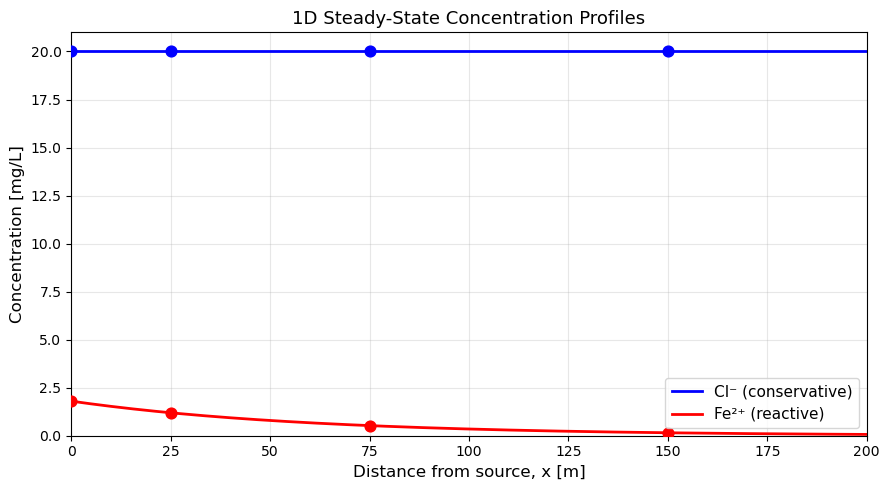

In [10]:
# ══════════════════════════════════════════════════════
#  Q2-3: Plot Cl- and Fe2+ concentration profiles
# ══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_profile, Cl_profile, 'b-', linewidth=2, label='Cl⁻ (conservative)')
ax.plot(x_profile, Fe_profile, 'r-', linewidth=2, label='Fe²⁺ (reactive)')

# Mark the specific x points
ax.scatter(x_points, [C_Cl(np.array([x]), C0_Cl) for x in x_points],
           color='blue', zorder=5, s=60)
ax.scatter(x_points, [C_Fe(x, C0_Fe, lambda_full) for x in x_points],
           color='red',  zorder=5, s=60)

ax.set_xlabel('Distance from source, x [m]', fontsize=12)
ax.set_ylabel('Concentration [mg/L]', fontsize=12)
ax.set_title('1D Steady-State Concentration Profiles', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, x_profile.max())
ax.set_ylim(0)
plt.tight_layout()
plt.show()

Question 2-3

(b) Discuss which species behaves more like a conservative plume? Which is reaction-limited? Explain using your results. 

Cl⁻ behaves as a conservative plume in this model. Its concentration stays constant at 20 mg/L across the entire 150 m flow path, which tells us nothing is removing it from solution. There’s no reaction term acting on Cl⁻, so it just moves with the groundwater without changing concentration.

Conversely, Fe²⁺ is reaction-limited. Its concentration drops steadily with distance because we included a first-order removal process (sorption/precipitation). The plot illustrates that the Fe²⁺ curve decreases exponentially, while Cl⁻ stays flat. The difference between the two curves shows that Fe²⁺ is being actively attenuated by reactions, while Cl⁻ is not.

(c) Explain how λ and L quantify plume extent and why Fe2+ has a shorter plume than Cl−.

The attenuation coefficient λ tells us how quickly the concentration decreases per meter of travel. Since λ = 0.0164 1/m, that means Fe²⁺ is losing concentration fairly steadily as it moves downgradient.

The attenuation length L=1/λ gives a more intuitive way to think about plume size. L ≈ 61 m. That means over about 61 meters, the concentration drops to roughly 37% of its original value (because e^−1≈0.37). By about 3L (~180 m), most of the Fe²⁺ would be gone.

Fe²⁺ has a shorter plume because λ is greater than zero, meaning it is being removed by a reaction as it moves downgradient. In contrast, Cl⁻ has no reaction term (λ ≈ 0), so its concentration does not decrease with distance. As a result, Fe²⁺ decays exponentially over tens of meters, while Cl⁻ remains constant and does not attenuate.

## Question 2 - Part 4 ##

Read the corresponding research paper (Ng et al, 2015) and discuss:

(a) Which redox reaction produces Fe2+ in the plume? 

Fe²⁺ in the plume is primarily produced by microbial reduction of Fe(III) minerals during biodegradation of petroleum hydrocarbons. As oxygen and nitrate are consumed near the source, microbes shift to using Fe(III) oxides as electron acceptors, reducing solid Fe(III) to dissolved Fe²⁺. 

(b) Why does Fe2+ not accumulate indefinitely? 

Fe²⁺ does not build up forever because it is removed by secondary reactions, mainly sorption to mineral surfaces and precipitation as secondary minerals (e.g., siderite, FeCO₃). So even though Fe²⁺ is being produced by iron reduction, it is simultaneously being removed by mineral reactions. This balance between production and removal prevents indefinite accumulation.

(c) How does CH4 production indicate terminal redox conditions? 

Methane generation is part of the evolving redox zonation within the plume. It indicates that the system has reached methanogenic conditions, which occur after more favorable electron acceptors (oxygen, nitrate, Fe(III) and sulfate) have been reduced and depleted. Methane formation reflects the terminal stage of anaerobic biodegradation, when microbes are using CO₂ as an electron acceptor.

(d) List two processes that reduce secondary plume concentrations.

1) Mineral precipitation (e.g., siderite formation removes Fe²⁺ from solution)
2) Sorption onto aquifer sediments (attenuates dissolved metals like Fe²⁺)
3) Also, outgassing (for CH₄ and CO₂) reduces plume concentrations


## Question 2 - Part 5 ##
Modify the Fe2+ model to include retardation due to sorption. According to Eq. 4 and the given retardation parameter, (a) calculate the new effective velocity.

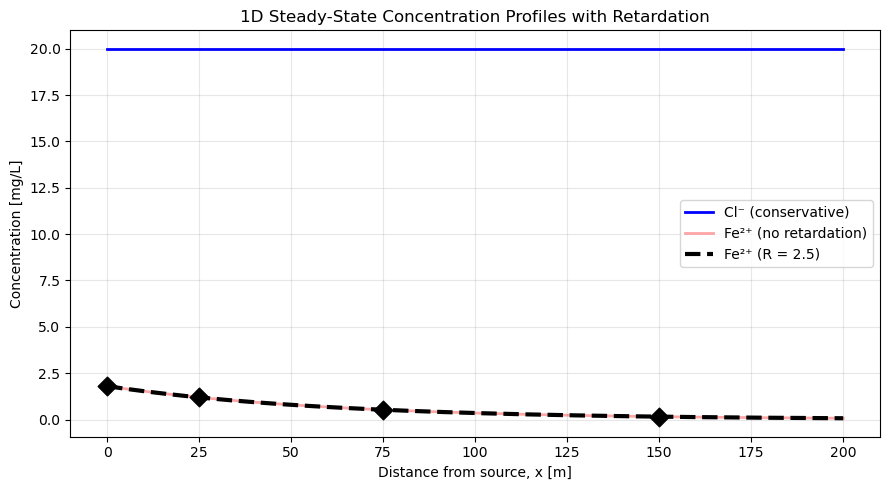

  Q2-5: Retardation Comparison
  Reference slide: 'Reactive solute reactive transport (with R term highlighted)'
  Governing equation 1D ADE: R * dC/dt = D * d²C/dx² - v * dC/dx - k*C
  Divide by R: dC/dt = (D/R) * d²C/dx² - (v/R) * dC/dx - (k/R)*C
  Effective retarded parameters:
    v_eff = v / R,   k_eff = k / R
--------------------------------------------------
  Retardation factor R       : 2.5
  Effective velocity v_eff   : 0.1200 m/day  (was 0.3)
  Effective removal  k_eff   : 0.0020 1/day  (was 0.005)
--------------------------------------------------
  Without retardation:
    λ       = 0.016398 1/m
    L = 1/λ = 60.98 m
  With retardation (R=2.5):
    λ       = 0.016398 1/m
    L = 1/λ = 60.98 m
--------------------------------------------------
  Retardation has NO effect on plume length.
  At steady state, R drops out — profiles are identical.


In [11]:
# ══════════════════════════════════════════════════════
#  Q2-5: Plot Cl- and Fe2+ concentration profiles with retardation due to sorption
# ══════════════════════════════════════════════════════

# ============================================================
# Eq. 4 (Reactive_Transport): Retardation effect on velocity
#   R * dC/dt = D * d²C/dx² - v * dC/dx - k*C
#
# Divide by R:
#   dC/dt = (D/R) * d²C/dx² - (v/R) * dC/dx - (k/R)*C
#
# At steady state, dC/dt = 0, so R drops out entirely.
# The retarded effective parameters are:
#   v_eff = v / R
#   k_eff = k / R
# Because k_eff/v_eff = k/v, lambda is unchanged and the
# steady-state concentration profile is identical with or without retardation.
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

# Conservative Cl-
ax.plot(x_profile, Cl_profile,
        color='blue', linewidth=2,
        label='Cl⁻ (conservative)')

# Fe²⁺ without retardation
ax.plot(x_profile, Fe_profile,
        color='red', linewidth=2, alpha=0.35,
        label='Fe²⁺ (no retardation)')

# ── Retardation calculation ─────────────────────────────
v_eff = v / R
k_eff = k / R
D_eff = alpha_L * v_eff

lambda_R = (v_eff / (2*D_eff)) * (1 - np.sqrt(1 + (4*k_eff*D_eff) / v_eff**2))
lambda_R = abs(lambda_R)
L_scale_R = 1 / lambda_R

Fe_profile_R = C_Fe(x_profile, C0_Fe, lambda_R)

# Fe²⁺ with retardation (dashed, on top)
ax.plot(x_profile, Fe_profile_R,
        color='black', linestyle='--',
        linewidth=3, zorder=10,
        label=f'Fe²⁺ (R = {R})')

ax.scatter(x_points,
           [C_Fe(x, C0_Fe, lambda_R) for x in x_points],
           color='black', s=90, zorder=15, marker='D')

ax.set_xlabel('Distance from source, x [m]')
ax.set_ylabel('Concentration [mg/L]')
ax.set_title('1D Steady-State Concentration Profiles with Retardation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Q5 Summary ───────────────────────────────────────────────────────────────
print(f"{'='*50}")
print(f"  Q2-5: Retardation Comparison")
print(f"{'='*50}")
print(f"  Reference slide: 'Reactive solute reactive transport (with R term highlighted)'")
print(f"  Governing equation 1D ADE: R * dC/dt = D * d²C/dx² - v * dC/dx - k*C")
print(f"  Divide by R: dC/dt = (D/R) * d²C/dx² - (v/R) * dC/dx - (k/R)*C")
print(f"  Effective retarded parameters:")
print(f"    v_eff = v / R,   k_eff = k / R")
print(f"{'-'*50}")
print(f"  Retardation factor R       : {R}")
print(f"  Effective velocity v_eff   : {v_eff:.4f} m/day  (was {v})")
print(f"  Effective removal  k_eff   : {k_eff:.4f} 1/day  (was {k})")
print(f"{'-'*50}")
print(f"  Without retardation:")
print(f"    λ       = {lambda_full:.6f} 1/m")
print(f"    L = 1/λ = {L_scale_full:.2f} m")
print(f"  With retardation (R={R}):")
print(f"    λ       = {lambda_R:.6f} 1/m")
print(f"    L = 1/λ = {L_scale_R:.2f} m")
print(f"{'-'*50}")

tol = 1e-6  # tolerance in metres

if abs(L_scale_R - L_scale_full) < tol:
    print(f"  Retardation has NO effect on plume length.")
    print(f"  At steady state, R drops out — profiles are identical.")
elif L_scale_R > L_scale_full:
    print(f"  Retardation INCREASES plume length by {L_scale_R - L_scale_full:.2f} m")
else:
    print(f"  Retardation DECREASES plume length by {L_scale_full - L_scale_R:.2f} m")

Q2-5

(b) Compare plume length with and without retardation.

At steady state, plume length with and without retardation are equal. Because ∂C/∂t=0, the retardation term R(∂C/∂t) drops out of the equation entirely. Retardation affects how fast the plume evolves over time, but since this model is in steady state, it does not change the final concentration profile C(x).